In [1]:
import pandas as pd
import numpy as np
import simplejson
import torch
import lightning as L
from Utils import get_tt_split

In [4]:
ln_data = pd.read_excel('../data/lymph_node_data.xlsx')
ln_data.head()

,Dummy ID,ROI,Age at Diagnosis (Calculated),Pathological Grade,Gender,Race,Therapeutic combination,Tm Laterality (R/L),Tumor subsite (BOT/Tonsil/Soft Palate/Pharyngeal wall/GPS/NOS),HPV/P16 status,...,F51-NeighborIntensityDifference25Coarseness,F51-NeighborIntensityDifference25Complexity,F51-NeighborIntensityDifference25Contrast,F51-NeighborIntensityDifference25TextureStrength,F52-NeighborIntensityDifference25Busyness,F52-NeighborIntensityDifference25Coarseness,F52-NeighborIntensityDifference25Complexity,F52-NeighborIntensityDifference25Contrast,F52-NeighborIntensityDifference25TextureStrength,F29-IntensityDirectLocalRangeMax
0,10001,GTVp1,54.394444,II,Male,White/Caucasion,Radiation alone,L,Tonsil,Unknown,...,0.106711,33601.28312,0.409756,7.080323,0.000076,0.106711,33601.28312,0.409756,7.080323,1162.0
1,10184,NaN,63.130556,II,Male,White/Caucasion,CC,L,Tonsil,Unknown,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,10009,GTVp1,55.447222,III,Female,White/Caucasion,Radiation alone,R,Tonsil,Unknown,...,0.081576,20486.62645,0.999399,10.800251,0.000184,0.081576,20486.62645,0.999399,10.800251,1109.0
3,10010,NaN,73.050000,III,Male,White/Caucasion,Radiation alone,Bilateral,NOS,Unknown,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,10069,GTVp1,60.525000,NaN,Male,White/Caucasion,IC+Radiation alone,L,Tonsil,Unknown,...,0.204842,10023.58332,0.192321,5.113107,0.000054,0.204842,10023.58332,0.192321,5.113107,1075.0


In [293]:
ln_data = ln_data.rename({'Dummy ID': 'id'},axis=1).set_index('id')
ln_data.head()

KeyError: "None of ['id'] are in the columns"

In [294]:
radiomic_cols = [c for c in ln_data.columns if c[0] == 'F' and '-' in c]
rm = ln_data[radiomic_cols].fillna(0)
rm.head()

,F2-GrayLevelCooccurenceMatrix2590-4ClusterTendendcy,F2-GrayLevelCooccurenceMatrix2590-5ClusterTendendcy,F2-GrayLevelCooccurenceMatrix2590-6ClusterTendendcy,F2-GrayLevelCooccurenceMatrix2590-7ClusterTendendcy,F2-GrayLevelCooccurenceMatrix25135-1ClusterTendendcy,F2-GrayLevelCooccurenceMatrix25135-2ClusterTendendcy,F2-GrayLevelCooccurenceMatrix25135-3ClusterTendendcy,F2-GrayLevelCooccurenceMatrix25135-4ClusterTendendcy,F2-GrayLevelCooccurenceMatrix25135-5ClusterTendendcy,F2-GrayLevelCooccurenceMatrix25135-6ClusterTendendcy,...,F51-NeighborIntensityDifference25Coarseness,F51-NeighborIntensityDifference25Complexity,F51-NeighborIntensityDifference25Contrast,F51-NeighborIntensityDifference25TextureStrength,F52-NeighborIntensityDifference25Busyness,F52-NeighborIntensityDifference25Coarseness,F52-NeighborIntensityDifference25Complexity,F52-NeighborIntensityDifference25Contrast,F52-NeighborIntensityDifference25TextureStrength,F29-IntensityDirectLocalRangeMax
ID,,,,,,,,,,,,,,,,,,,,,
10001,2169.381070,2004.708495,1858.470787,1734.634735,1996.668300,1542.119170,1419.922264,1420.754836,1433.812698,1410.230095,...,0.106711,33601.28312,0.409756,7.080323,0.000076,0.106711,33601.28312,0.409756,7.080323,1162.0
10184,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0
10009,2503.705527,2258.113520,1995.820593,1703.374488,2308.163473,1649.224538,1586.523120,1631.963532,1660.486979,1709.550840,...,0.081576,20486.62645,0.999399,10.800251,0.000184,0.081576,20486.62645,0.999399,10.800251,1109.0
10010,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0
10069,957.125333,849.701668,794.556584,739.654003,1127.261727,864.073903,820.264055,835.117929,840.909730,837.959249,...,0.204842,10023.58332,0.192321,5.113107,0.000054,0.204842,10023.58332,0.192321,5.113107,1075.0


In [498]:
train_ids, test_ids = get_tt_split()
train_ids = [c for c in rm.index.values if c not in test_ids]
rm.loc[train_ids].shape,rm.loc[test_ids].shape

((497, 3367), (147, 3367))

In [512]:

class Encoder(torch.nn.Module):
    def __init__(self,
                 input_shape,
                 embedding_size = 5,
                 hidden_dims = [200,200],
                 input_dropout = .1,
                 pre_embedding_dropout = 0,
                 activation = torch.nn.ReLU,
                ):
        super().__init__()
        modules = []
        self.input_dropout = torch.nn.Dropout(input_dropout)
        currdim = input_shape
        for hd in hidden_dims:
            modules.append(torch.nn.Linear(currdim, hd))
            if activation is not None:
                modules.append(activation())
            currdim = hd
        self.hidden_layers = torch.nn.Sequential(*modules)
        self.embedding_layer_mean = torch.nn.Linear(currdim,embedding_size)
        self.embedding_layer_std = torch.nn.Linear(currdim,embedding_size)
        self.pre_embedding_dropout = torch.nn.Dropout(pre_embedding_dropout)
        

    def forward(self, x):
        x = self.input_dropout(x)
        x = self.hidden_layers(x)
        x = self.pre_embedding_dropout(x)
        mu = self.embedding_layer_mean(x)
        logvar = self.embedding_layer_std(x)
        
        return mu,logvar

class Decoder(torch.nn.Module):
    def __init__(self,
                 output_shape,
                 embedding_size = 5,
                 hidden_dims = [200,200],
                 penultimate_dropout = .1,
                 embedding_dropout = 0,
                 activation = None,
                ):
        super().__init__()
        modules = []
        currdim = embedding_size
        for hd in hidden_dims:
            modules.append(torch.nn.Linear(currdim, hd))
            if activation is not None:
                modules.append(activation())
            currdim = hd
        self.hidden_layers = torch.nn.Sequential(*modules)
        self.embedding_dropout = torch.nn.Dropout(embedding_dropout)
        self.penultimate_dropout = torch.nn.Dropout(penultimate_dropout)
        self.output_layer = torch.nn.Linear(currdim,output_shape)
        
    def reparameterize(self, mu, logvar):
        """
        Reparameterization trick to sample from N(mu, var) from
        N(0,1).
        :param mu: (Tensor) Mean of the latent Gaussian [B x D]
        :param logvar: (Tensor) Standard deviation of the latent Gaussian [B x D]
        :return: (Tensor) [B x D]
        """
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return eps * std + mu
    
        
    def final_transform(self,x):
        #for subclass options
        return x

    def forward(self, xmu,xlogvar):
        x = self.reparameterize(xmu,xlogvar)
        x = self.embedding_dropout(x)
        x = self.hidden_layers(x)
        x = self.penultimate_dropout(x)
        x = self.output_layer(x)
        return self.final_transform(x)
    
class RadiomicsVAE(L.LightningModule):
    def __init__(self, input_shape, embedding_size,encoder_args={},decoder_args={},kld_weight=.01,mse_weight=1,lr=.001):
        self.lr=lr
        super().__init__()
        self.encoder = Encoder(input_shape,embedding_size=embedding_size,**encoder_args)
        self.decoder = Decoder(input_shape,embedding_size=embedding_size,**decoder_args)
        self.kld_weight = kld_weight
        self.mse_weight = mse_weight
        

    def training_step(self, batch, batch_idx):
        # training_step defines the train loop.
        x = batch
        x = x.view(x.size(0), -1)
        mu,lvar = self.encoder(x)
        kld_loss = torch.mean(-0.5 * torch.sum(1 + lvar - mu ** 2 - lvar.exp(), dim = 1), dim = 0)
        x_hat = self.decoder(mu,lvar)
        mse_loss = torch.nn.functional.mse_loss(x_hat, x)
        
        return self.mse_weight*mse_loss + self.kld_weight*kld_loss
    
    def validation_step(self, batch, batch_idx):
        # training_step defines the train loop.
        x = batch
        x = x.view(x.size(0), -1)
        mu,lvar = self.encoder(x)
        kld_loss = torch.mean(-0.5 * torch.sum(1 + lvar - mu ** 2 - lvar.exp(), dim = 1), dim = 0)
        self.log('val_kld_loss',kld_loss)
        x_hat = self.decoder(mu,lvar)
        mse_loss = torch.nn.functional.mse_loss(x_hat, x)
        self.log("val_mse_loss",mse_loss)
        val_loss = self.mse_weight*mse_loss + self.kld_weight*kld_loss
        self.log("val_loss",val_loss)

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=self.lr)
        return optimizer
    
model = RadiomicsVAE(x.shape[1],5,lr=.0001,kld_weight=0.1)
model

RadiomicsVAE(
  (encoder): Encoder(
    (input_dropout): Dropout(p=0.1, inplace=False)
    (hidden_layers): Sequential(
      (0): Linear(in_features=3367, out_features=200, bias=True)
      (1): ReLU()
      (2): Linear(in_features=200, out_features=200, bias=True)
      (3): ReLU()
    )
    (embedding_layer_mean): Linear(in_features=200, out_features=5, bias=True)
    (embedding_layer_std): Linear(in_features=200, out_features=5, bias=True)
    (pre_embedding_dropout): Dropout(p=0, inplace=False)
  )
  (decoder): Decoder(
    (hidden_layers): Sequential(
      (0): Linear(in_features=5, out_features=200, bias=True)
      (1): Linear(in_features=200, out_features=200, bias=True)
    )
    (embedding_dropout): Dropout(p=0, inplace=False)
    (penultimate_dropout): Dropout(p=0.1, inplace=False)
    (output_layer): Linear(in_features=200, out_features=3367, bias=True)
  )
)

In [513]:
from lightning.pytorch.callbacks.early_stopping import EarlyStopping

BATCHSIZE = 50
[xtrain,xval] = [torch.from_numpy(rm.loc[ids].values.astype('float')).type(torch.float32) for ids in [train_ids,test_ids]]
normalize = lambda xx: (xx - xtrain.mean(axis=0))/(xtrain.std(axis=0) + .1)
convert = lambda x: torch.utils.data.DataLoader(normalize(x),batch_size=BATCHSIZE)
es = EarlyStopping(monitor='val_loss',mode='min',patience=20)
trainer = L.Trainer(max_epochs=1000,callbacks=[es])
torch.set_float32_matmul_precision('medium')
trainer.fit(model,convert(xtrain),convert(xval))

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name    | Type    | Params | Mode 
--------------------------------------------
0 | encoder | Encoder | 715 K  | train
1 | decoder | Decoder | 718 K  | train
--------------------------------------------
1.4 M     Trainable params
0         Non-trainable params
1.4 M     Total params
5.736     Total estimated model params size (MB)
17        Modules in train mode
0         Modules in eval mode


Sanity Checking: |                                        | 0/? [00:00<?, ?it/s]

/home/awentze2/anaconda3/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:424: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
/home/awentze2/anaconda3/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:424: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
/home/awentze2/anaconda3/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:298: The number of training batches (10) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |                                               | 0/? [00:00<?, ?it/s]

Validation: |                                             | 0/? [00:00<?, ?it/s]

...

Validation: |                                             | 0/? [00:00<?, ?it/s]

Validation: |                                             | 0/? [00:00<?, ?it/s]

Validation: |                                             | 0/? [00:00<?, ?it/s]

Validation: |                                             | 0/? [00:00<?, ?it/s]

IOPub message rate exceeded.
The notebook server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--NotebookApp.iopub_msg_rate_limit`.

Current values:
NotebookApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
NotebookApp.rate_limit_window=3.0 (secs)



In [514]:
xall = torch.concat([xtrain,xval],axis=0)
trainer.validate(model,convert(xall))

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Validation: |                                             | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
     Validate metric           DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
      val_kld_loss          0.9304739236831665
        val_loss            0.4232373535633087
      val_mse_loss           0.330189973115921
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


[{'val_kld_loss': 0.9304739236831665,
  'val_mse_loss': 0.330189973115921,
  'val_loss': 0.4232373535633087}]

In [515]:
with torch.no_grad():
    embedding = model.decoder.reparameterize(*model.encoder(normalize(torch.from_numpy(rm.values.astype(np.float32))))).detach().cpu().numpy()
embedding

array([[ 1.5903348 ,  0.31613877,  0.07744928, -0.7356267 ,  0.03781316],
       [-0.395571  ,  0.81072056,  1.3551602 ,  1.6394223 , -1.7686328 ],
       [ 0.09337667, -0.85435325, -0.49628648,  0.5670354 , -0.17501892],
       ...,
       [ 0.3292528 ,  0.27090377, -0.11619215, -0.07610577,  0.7877023 ],
       [-0.64561874,  1.2873559 , -0.20717008,  1.0393453 ,  1.1831386 ],
       [-0.55583346,  0.3436441 ,  0.9519533 , -0.03138325,  0.90408945]],
      dtype=float32)

In [527]:
embed_df = pd.DataFrame(embedding,index=rm.index)
embed_df.columns = ['radiomics_embedding_'+str(i) for i in embed_df.columns]
embed_df.to_csv('../data/radiomics_embeddings.csv')
pd.read_csv('../data/radiomics_embeddings.csv')

,id,radiomics_embedding_0,radiomics_embedding_1,radiomics_embedding_2,radiomics_embedding_3,radiomics_embedding_4
0,10001,1.590335,0.316139,0.077449,-0.735627,0.037813
1,10184,-0.395571,0.810721,1.355160,1.639422,-1.768633
2,10009,0.093377,-0.854353,-0.496286,0.567035,-0.175019
3,10010,-1.070785,0.605126,1.275430,-0.774755,-1.213821
4,10069,-1.202750,0.402617,0.962809,0.501570,-0.194195
...,...,...,...,...,...,...
639,74,1.597451,-0.223655,-0.818685,0.837198,-0.176768
640,233,0.418251,-0.422374,-1.283111,-0.690219,0.422503
641,165,0.329253,0.270904,-0.116192,-0.076106,0.787702
642,5084,-0.645619,1.287356,-0.207170,1.039345,1.183139


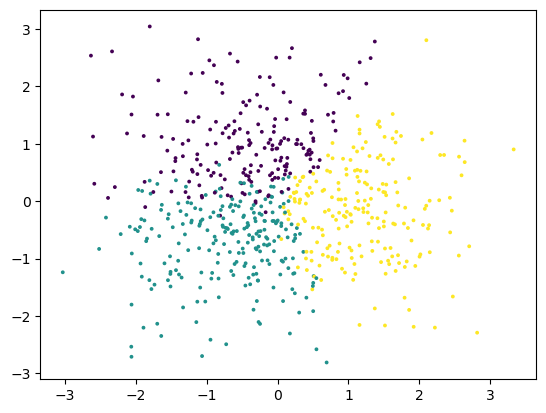

In [520]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, OPTICS, DBSCAN
from sklearn.decomposition import PCA
# clusters = DBSCAN(eps=.1).fit_predict(embedding)
# clusters = OPTICS().fit_predict(embedding)
clusters = KMeans(3).fit_predict(embedding)
plotvals = embedding
if embedding.shape[1] > 2:
    plotvals = PCA(2).fit_transform(embedding)
plt.scatter(plotvals[:,0],plotvals[:,1],s=3,c=clusters)

In [521]:
temp = pd.Series(clusters,rm.index)
temp.name = 'cluster'
temp.to_csv('../data/radiomics_clusters.csv')
pd.read_csv('../data/radiomics_clusters.csv').set_index("id")

,cluster
id,
10001,1
10184,2
10009,1
10010,2
10069,0
...,...
74,1
233,1
165,1


In [528]:
from Preprocessing import DTDataset
from Constants import Const

df = DTDataset().get_data()
df = df[Const.decisions]
df = df.merge(temp,on='id')
df['sequence'] = df[Const.decisions].apply(lambda x: ''.join([str(i) for i in x]),axis=1)
df.head()

/home/awentze2/git_repos/DigitalTwinVis/python/Preprocessing.py:186: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dummy_df = pd.get_dummies(df[to_onehot].fillna(0).astype(str),drop_first=False)
/home/awentze2/git_repos/DigitalTwinVis/python/Preprocessing.py:292: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  processed_df = preprocess_dt_data(df,self.ln_cols).fillna(0).drop(['DLT_Type'],axis=1)


,Decision 1 (Induction Chemo) Y/N,Decision 2 (CC / RT alone),Decision 3 Neck Dissection (Y/N),cluster,sequence
id,,,,,
3,0,1,0,2,010
5,0,1,0,1,010
6,0,1,0,2,010
7,0,0,0,2,000
8,0,0,0,0,000


In [529]:
tempdf = pd.get_dummies(df['cluster']).astype('int').merge(df['sequence'],on='id')
tempdf1 = tempdf.groupby('sequence').mean()
tempdf1.columns = ['cluster' + str(c) for c in tempdf1.columns]
tempdf2 = tempdf.groupby('sequence').sum()
tempdf2.columns = ['clustersum' + str(c) for c in tempdf2.columns]
tempdf = tempdf1.merge(tempdf2,on='sequence')
tempdf

,cluster0,cluster1,cluster2,clustersum0,clustersum1,clustersum2
sequence,,,,,,
000,0.298246,0.315789,0.385965,17,18,22
001,0.272727,0.363636,0.363636,3,4,4
010,0.322870,0.376682,0.300448,72,84,67
011,0.352941,0.294118,0.352941,18,15,18
100,0.355556,0.244444,0.400000,16,11,18
101,0.076923,0.384615,0.538462,1,5,7
110,0.350000,0.380000,0.270000,35,38,27
111,0.194444,0.444444,0.361111,7,16,13


In [530]:
from sklearn.feature_selection import chi2
chi2(pd.get_dummies(df.sequence),pd.get_dummies(df['cluster']).astype('int'))[1]

array([0.64027746, 0.94811386, 0.66086095, 0.64493037, 0.28423303,
       0.12747388, 0.45471766, 0.27673329])

In [531]:
chi2(df[Const.decisions],pd.get_dummies(df['cluster']).astype('int'))[1]

array([0.94448171, 0.58515764, 0.39086055])

<Axes: xlabel='sequence'>

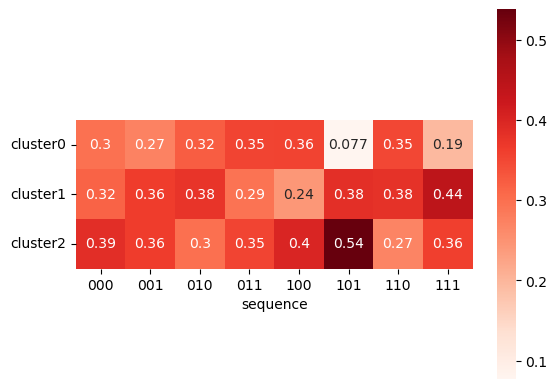

In [532]:
import seaborn as sns

sns.heatmap(tempdf1.T,
              annot=True,
              square=True,
              cmap='Reds')

Text(0, 0.5, 'cluster %')

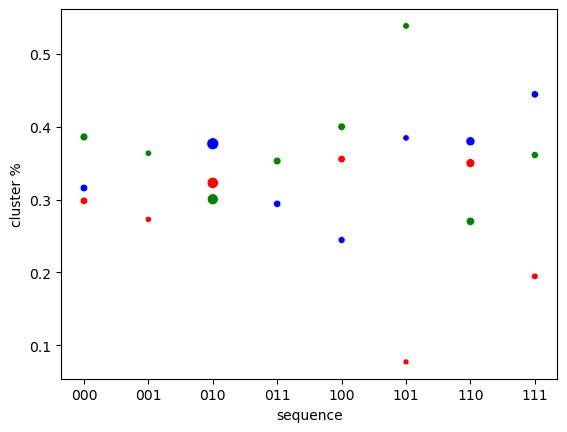

In [533]:
fig,ax=plt.subplots(1,1)
plotstuff = tempdf.copy()
maxsize = plotstuff[[c for c in plotstuff.columns if 'clustersum' in c]].max().max()
colors=['red','blue','green','teal','pink','purple','grey','black']
i=0
for col1,col2 in zip(tempdf1.columns,tempdf2.columns):
    sns.scatterplot(plotstuff,
               x='sequence',
               y=col1,
                size=col2,
                    color=colors[i],
                    legend=False,
                    ax=ax,
                    size_norm=(1,maxsize)
                   )
    i+=1
ax.set_ylabel('cluster %')

In [534]:
df.groupby('sequence').count()

,Decision 1 (Induction Chemo) Y/N,Decision 2 (CC / RT alone),Decision 3 Neck Dissection (Y/N),cluster
sequence,,,,
000,57,57,57,57
001,11,11,11,11
010,223,223,223,223
011,51,51,51,51
100,45,45,45,45
101,13,13,13,13
110,100,100,100,100
111,36,36,36,36
